<a href="https://colab.research.google.com/github/FredyVG15/Entregas-/blob/main/Practica_Pronosticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Resultados**

Cierre de precios estimados al 19 de Junio
- Índice S&P500
  

```
 8227.745896150094 USD
```


- Bono del tesoro de EEUU corto plazo ETD BIL


```
  97.21116615982504 USD
```



**Integrantes**

* Karla García Ávila
* Carlos Balam Huerta Coronel
* Fredy Vázquez González


## ***Predicción precio de cierre del S&P500 para el 19 de junio del 2026***

Para realizar la predicción del precio de cierre de este activo, hicimos uso de datos históricos del periodo del 7 de abril del 2021 al 15 de mayo del 2026, tomando el precio de cierre que hubo en cada uno de los días habiles dentro de ese periodo.

In [ ]:
import yfinance as yf
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from random import choices, gauss
from scipy.stats import pearsonr
import pandas as pd
import math as mt
from scipy.linalg import ldl
datossp = yf.download('^GSPC', start='2021-04-07', end='2026-05-16')

/tmp/ipykernel_5175/795631729.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datossp = yf.download('^GSPC', start='2021-04-07', end='2026-05-16')
[*********************100%***********************]  1 of 1 completed


Posteriormente, graficamos los precios de cierre para poder visualizar mejor la tendencia que tiene este activo, además de calcular los rendimientos que se tuvieron y de igual forma, se graficaron para poder hacer nuestro análisis.

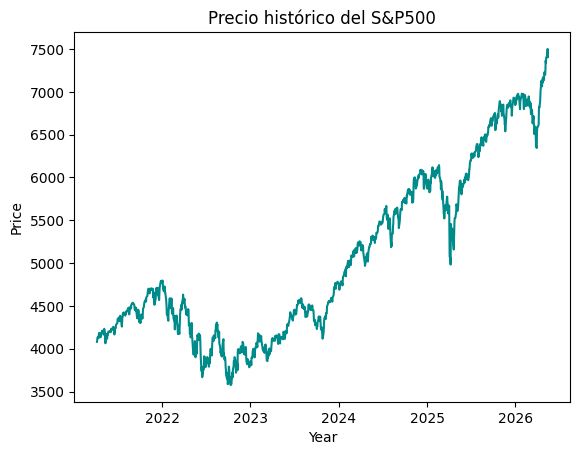

<Axes: ylabel='Count'>

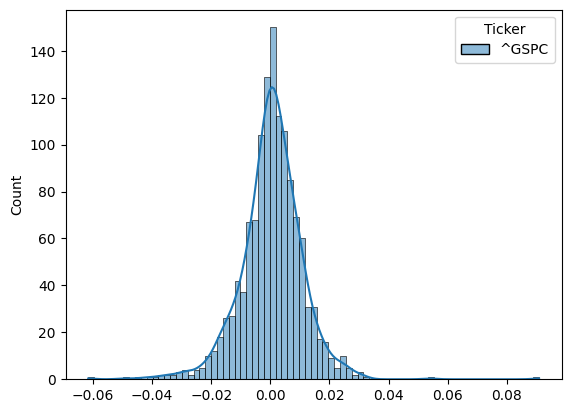

In [ ]:
plt.plot(datossp['Close'], color = 'darkcyan')
plt.ylabel('Price')
plt.xlabel('Year')
plt.title('Precio histórico del S&P500')
plt.show()
rend = np.log(datossp['Close'] / datossp['Close'].shift(1))
yields = np.array(rend.dropna())
sns.histplot(rend, kde=True)

La primera gráfica muestra la evolución histórica del precio de SP&500 entre 2021 y 2026.Se observa una tendencia alcista de largo plazo, ya que el valor del activo aumenta de aproximadamente 4100 a cerca de 7000 puntos durante el periodo analizado.

El comportamiento no es completamente estable debido a que existen episodios de alta volatilidad y correcciones importantes, durante 2022 y parte de 2025, se presentan caídas significativas seguidas de procesos de recuperación.

A partir de 2023 el activo retoma una trayectoria de crecimiento sostenido, alcanzando máximos históricos hacia 2026. Aunque al final de la serie se aprecia una ligera disminución en el precio, la tendencia general continúa siendo positiva.

En conclusión, se refleja un mercado con crecimiento sostenido en el largo plazo, acompañado de fluctuaciones y periodos de incertidumbre característicos de los activos financieros.

La segunda gráfica muestra la distribución de los rendimientos diarios del S&P500 (^GSPC). Se observa que la mayoría de los rendimientos se concentran alrededor de cero, indicando que los cambios diarios suelen ser pequeños.


La distribución tiene una forma similar a una campana, cercana a una distribución normal, aunque presenta colas más amplias en ambos extremos, lo que refleja la existencia de movimientos extremos y periodos de alta volatilidad.

Para el cálculo del  precio a futuro hicimos una valuación por uso de trayectorias.

Para esto calculamos el rendimiento esperado anualizado y la volatilidad de los rendimientos anualizada, que son los parámetros necesarios para nuestra valuación.

In [ ]:
#Parámetros
M = 10**4
n = 25
S0 = 7408.5  # Precio en el tiempo t=0
T = 25/252    # Horizonte de tiempo 19 de junio
dt = T/n
r = np.mean(yields) * 252
s = np.std(yields) * np.sqrt(252)

Se generan variables normales estándar de las que haremos uso más adelante mediante Box-Muller.

In [ ]:
def BM():
  u1 = np.random.random()
  u2 = np.random.random()
  z1 = np.sqrt(-2*np.log(u1))*np.cos(2*np.pi*u2)
  z2 = np.sqrt(-2*np.log(u1))*np.sin(2*np.pi*u2)

  return z1, z2

A continuación se simulan trayectorias posibles por método de Monte Carlo utilizando un modelo de Movimiento Browniano Geométrico (GBM), del precio del S&P 500 y las reorganizamos en una matriz.

In [ ]:
#Simulación de precios
values = []
while len(values)<M*n:
  z1, z2 = BM()
  values.extend([z1,z2])

Z = np.array(values[:M*n]).reshape(n,M)
term = (r-.5*s**2)*dt + s*np.sqrt(dt)*Z
paths = np.cumsum(term, axis = 0)
ST = S0*np.exp(paths)
Si = np.full((1,M), S0)
ST1 = np.concatenate([Si, ST]) #Matriz completa

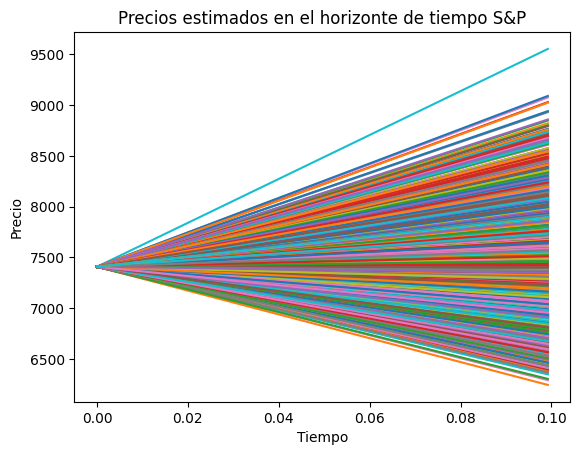

In [ ]:
#Gráfico
for price in range(M):
  plt.plot([0,T],[S0,ST[-1,price]])
plt.title('Precios estimados en el horizonte de tiempo S&P')
plt.xlabel('Tiempo')
plt.ylabel('Precio')
plt.show()

El gráfico muestra las trayectorias simuladas del precio del activo a lo largo del horizonte temporal(25 días hábiles). Cada línea representa una posible evolución futura del precio bajo las mismas condiciones iniciales.

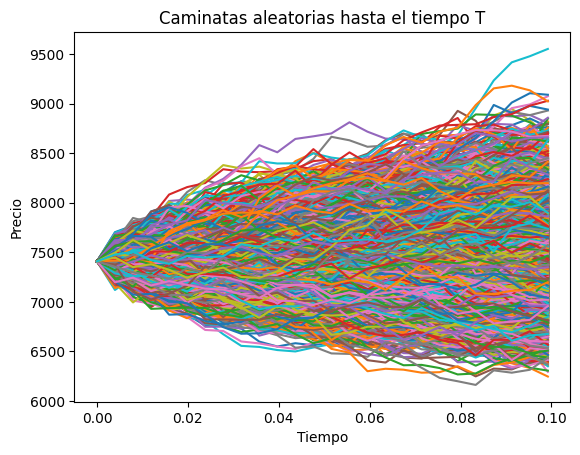

In [ ]:
#Gráfico
delta = np.linspace(0, T, n+1)
plt.plot(delta,ST1)
plt.title('Caminatas aleatorias hasta el tiempo T')
plt.xlabel('Tiempo')
plt.ylabel('Precio')
plt.show()

Esta gráfica muestra las trayectorias completas del precio del activo a lo largo del tiempo, generadas mediante simulación Monte Carlo bajo un modelo de GBM.
A diferencia del caso anterior, aquí cada trayectoria incorpora la componente aleatoria en cada instante de tiempo, lo que resulta en caminos irregulares y realistas.

La simulación muestra que, bajo los supuestos del modelo GBM, el precio del activo presenta una evolución relativamente estable con variaciones acotadas, lo cual es coherente con su perfil de riesgo.

A continuación se hizo uso del método bootstrap con el objetivo de analizar la variabilidad y el posible error al estimar estadísticas como la media y los percentiles del precio simulado en el tiempo T.

Al final se obtiene una media esperada y se tomará la media del percentile 96 como el valor que mejor se ajusta al precio estimado.

In [ ]:
#Bootstrap
#Compararación del error que se comete utilizando la media y percentiles
st, percentiles, means, sumean, superce = ST1[-1,:], [], [],0,0#Tomamos el precio simulado en el horizonte del tiempo
nsim = 10000
for k in range(nsim):
  muestra = choices(st, k = M)
  means1 = np.mean(muestra) #tomamos la media
  perce = np.percentile(muestra,96) #tomamos el percentil 96 de la muestra
  percentiles.append(perce)
  means.append(means1)
  #sumean += (means1 - m)**2
  #superce += (perce - m)**2

#print('Precio de mercado ',{m})
print('Media estimada ', {np.mean(means)})
print('Media de los percentiles ', {np.mean(percentiles)})#El valor que tomaremos como respuesta
#print('MSE ', {sumean/nsim})
#print('MSE percentiles ', {superce/nsim})#MSE = VAR+ SESGO
#print('Bias mean', np.sqrt(sumean/nsim-np.var(means)))
#print('Bias percentiles', np.sqrt(superce/nsim-np.var(percentiles)))

Media estimada  {np.float64(7496.400893662563)}
Media de los percentiles  {np.float64(8227.745896150094)}


In [ ]:
np.percentile(ST1[-1,:],96)

np.float64(8228.671805996437)

## **Predicción del precio futuro de un activo financiero de bajo riesgo,el ETF BIL(bonos del Tesoro de Estados Unidos de corto plazo).**




Decidimos escoger el ETF BIL ya que a pesar de no dar rendimientos tan altos el riesgo es muchisimo menor debido a su volatilidad baja a diferencia de activos financieros en los que la volatilidad es alta y por lo tanto su comportamiento no es tan predecible

Para realizar la predicción del precio de cierre de este activo, haremos uso de datos históricos del periodo del 1 de enero del 2021 al 15 de mayo del 2026, tomando el precio de cierre que hubo en cada uno de los días habiles dentro de ese periodo

/tmp/ipykernel_5175/4162387976.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download("IEF",start='2021-04-07', end='2026-05-16')
[*********************100%***********************]  1 of 1 completed


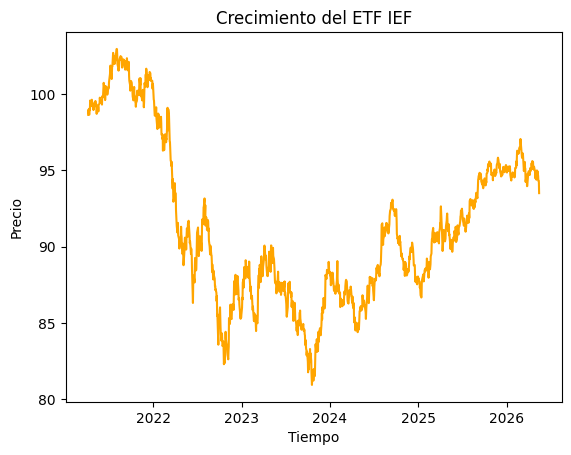

In [ ]:
# Predicción con bono gubernamental: ETF IEF
# Datos históricos

datos = yf.download("IEF",start='2021-04-07', end='2026-05-16')

# Precio de cierre
cierres = datos["Close"]
plt.title("Crecimiento del ETF IEF")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.plot(datos['Close'], color = 'orange')
plt.show()

Calculamos el rendimiento esperado anualizado y la volatilidad de los rendimientos anualizada

In [ ]:
#rendimientos
rend_ETF = np.log(cierres / cierres.shift(1))
rend_ETF = rend_ETF.dropna()
yields_ETF = np.array(rend_ETF)

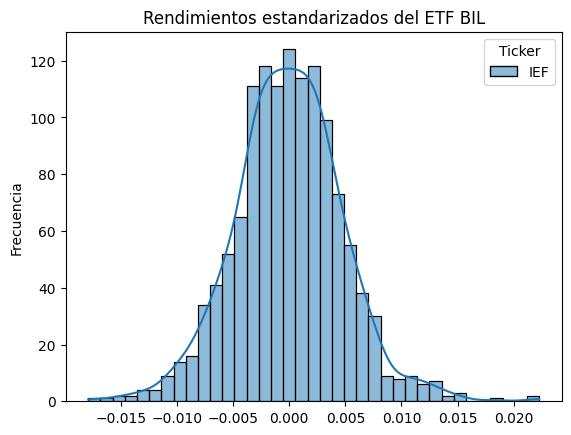

In [ ]:
# Histograma de rendimientos
sns.histplot(rend_ETF, kde = True)
plt.title("Rendimientos estandarizados del ETF BIL")
plt.ylabel("Frecuencia")
plt.show()

La gráfica presenta la distribución de los rendimientos estandarizados del ETF BIL mediante un histograma y una curva de densidad.

Se observa que la mayoría de los rendimientos se concentran alrededor de cero, mostrando una distribución aproximadamente normal y relativamente simétrica. Esto indica que las variaciones diarias del ETF suelen ser pequeñas y estables.

Además, la baja dispersión de los datos refleja una volatilidad reducida, característica esperada en instrumentos respaldados por bonos del Tesoro de Estados Unidos de corto plazo.

 Aunque existen algunos valores extremos en ambos lados de la distribución, su frecuencia es baja, lo que confirma el perfil conservador y de bajo riesgo del ETF BIL.


In [ ]:
# Parametros del modelo
S0_ETF = float(cierres.iloc[-1])   # precio inicial actual
r_ETF = np.mean(yields_ETF) * 252          # rendimiento anualizado
s_ETF = np.std(yields_ETF) * np.sqrt(252)  # volatilidad anualizada

print("Precio inicial S0:", S0_ETF)
print("Rendimiento anualizado r:", r_ETF)
print("Volatilidad anualizada s:", s_ETF)

Precio inicial S0: 93.51000213623047
Rendimiento anualizado r: -0.01050138255638878
Volatilidad anualizada s: 0.07637470923710325


/tmp/ipykernel_5175/839591932.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0_ETF = float(cierres.iloc[-1])   # precio inicial actual


A partir de los datos históricos obtenidos de Yahoo Finance, nos permitió identificar un precio inicial de aproximadamente **$93.51** USD por participación.

Entonces, el cálculo de los rendimientos logarítmicos mostró un  rendimiento anualizado de -**1.05%**, lo que refleja un crecimiento moderado y consistente con instrumentos financieros de renta fija de bajo riesgo.

Por otra parte, la **volatilidad** anualizada estimada fue de **7.64%**, indicando que las fluctuaciones del precio del ETF son relativamente reducidas en comparación con los activos de renta variable.


In [ ]:
# Simulación de  Monte Carlo
values_ETF = []
while len(values_ETF)<M*n:
  z1, z2 = BM()
  values_ETF.extend([z1,z2])

Z_ETF = np.array(values_ETF[:M*n]).reshape(n,M)
term_ETF = (r_ETF - 0.5*s_ETF**2)*dt + s_ETF*np.sqrt(dt)*Z_ETF
paths_ETF = np.cumsum(term_ETF, axis=0)
ST_ETF = S0_ETF * np.exp(paths_ETF)
Si_ETF = np.full((1, M), S0_ETF)
ST1_ETF = np.concatenate([Si_ETF, ST_ETF])#Matriz acumulada dt hasta T

In [ ]:
#Resultados
print("Precio esperado con simulación normal:", np.mean(ST1_ETF[-1, :]))
print("Desviación estándar normal:", np.std(ST1_ETF[-1, :]))

print("Percentil 5%:", np.percentile(ST1_ETF[-1, :], 5))
print("Percentil 50%:", np.percentile(ST1_ETF[-1, :], 50))
print("Percentil 95%:", np.percentile(ST1_ETF[-1, :], 95))

Precio esperado con simulación normal: 93.4365723895302
Desviación estándar normal: 2.22852628826582
Percentil 5%: 89.80166059997121
Percentil 50%: 93.41057853758396
Percentil 95%: 97.17748845171681


Los resultados de la simulación Monte Carlo, estimó un **precio esperado** de aproximadamente **97.1775** USD, lo que indica una variación moderada respecto al precio inicial del activo.

La **desviación estándar** obtenida fue de **2.29**, reflejando que las fluctuaciones esperadas del precio son relativamente pequeñas, confirmando el bajo nivel de riesgo asociado al ETF.

Considerando el análisis de percentiles arrojó que:


*   Existe un 5% de probabilidad de que el precio sea menor a 89.8 USD.
*  El valor central o mediano estimado es de aproximadamente 93.41 USD.
*   Existe un 95% de probabilidad de que el precio permanezca por debajo de 97.17 USD.

Los resultados indican que el ETF BIL mantiene una trayectoria relativamente estable y con variaciones limitadas.

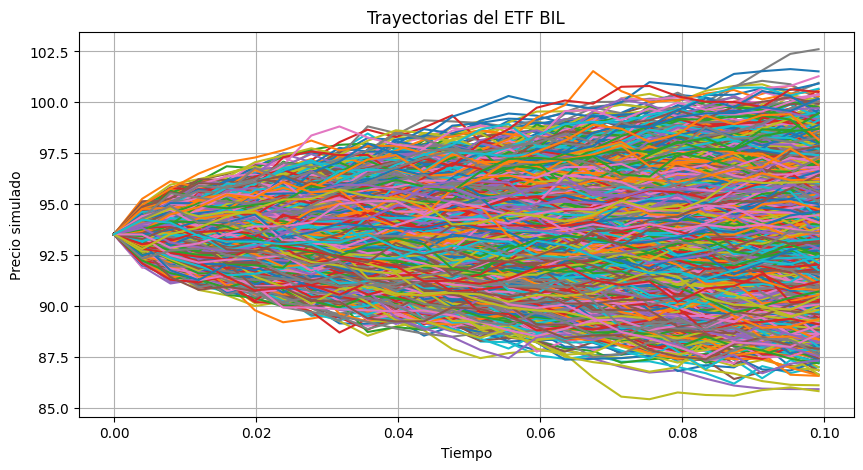

In [ ]:
#Construcción de trayectoras simuladas
delta = np.linspace(0, T, n+1)
plt.figure(figsize=(10,5))
plt.plot(delta, ST1_ETF)
plt.title("Trayectorias del ETF BIL")
plt.xlabel("Tiempo")
plt.ylabel("Precio simulado")
plt.grid()
plt.show()

La gráfica muestra múltiples trayectorias simuladas del precio del ETF BIL a lo largo del tiempo. Cada línea representa una posible evolución futura del precio basada en el comportamiento histórico del activo.

Se observa que la mayoría de los escenarios permanecen agrupados en un rango relativamente estrecho, aproximadamente entre 88 y 96 unidades, lo cual indica una baja volatilidad y un comportamiento estable del ETF. Esto es consistente con la naturaleza conservadora de BIL, al estar respaldado por bonos del Tesoro de Estados Unidos de corto plazo.

Entonces, aunque algunas trayectorias presentan ligeras tendencias alcistas o bajistas, la simulación refleja que el ETF mantiene una dinámica estable y de bajo riesgo.



In [ ]:
# Bootstrap
st = ST1_ETF[-1, :]
N = len(st)
nsim = 10000
medias = []
percentiles = []

for k in range(nsim):
    muestra_ETF = choices(st, k=N)
    media_muestra = np.mean(muestra_ETF)
    percentil_muestra = np.percentile(muestra_ETF, 95)
    medias.append(media_muestra)
    percentiles.append(percentil_muestra)


print("Media estimada por bootstrap:", np.mean(medias))
print("Percentil 95 estimado por bootstrap:", np.mean(percentiles))#El valor que tomaremos como respuesta


Media estimada por bootstrap: 93.41897406297076
Percentil 95 estimado por bootstrap: 97.21116615982504


El método Bootstrap nos permitió realizar una estimación estadística robusta a partir de los resultados obtenidos en la simulación Monte Carlo.

ES asi que se estimó una media del precio cercana a 97.21 USD, valor prácticamente consistente con el promedio obtenido en la simulación original.


La cercanía entre los resultados bootstrap y los obtenidos previamente nos indican que  que el modelo presenta consistencia estadística y baja sensibilidad a variaciones muestrales.

En conclusión , el uso del método bootstrap fortaleció la confiabilidad de nuestro  análisis presentado.

## **CONCLUSIÓN**

Llevar a cabo un análisis de predicción sobre un ETF de bonos del Tesoro a corto plazo, como el BIL, y contrastarlo con el S&P 500, resulta fundamental para comprender el comportamiento de activos con naturalezas opuestas.

 Por un lado, el S&P 500 ofrece exposición a la renta variable, asumiendo una mayor volatilidad; por el otro, el BIL brinda la estabilidad de la renta fija con el respaldo del gobierno estadounidense. La gran ventaja de estudiar el BIL radica en que funge como un excelente indicador de la tasa libre de riesgo, garantizando movimientos de mercado mucho más previsibles frente a las fluctuaciones del S&P 500

## Apendice

In [ ]:
#Creando un portafolio S&P con las 11 compañías mas representativas del índice
stocks = ['NVDA','GOOGL','GOOG','AAPL','MSFT','AMZN','AVGO','TSLA', 'META', 'WMT','BRK-B']
#Capitalización del mercado
market_cap = np.array([5.50,4.80,4.80,4.44,3.09,2.82,2.02,1.66,1.57,1.05,1.04])
weights = market_cap/np.sum(market_cap)

def extraccion(symbols):
  datossp = yf.download(symbols, start='2023-04-07', end='2026-04-08')
  rend = np.log(datossp['Close'] / datossp['Close'].shift(1))
  yields = np.array(rend.dropna())
  r = np.mean(yields)
  s = np.std(yields)
  matrix_cov = np.cov(yields, rowvar=False)
  return r, s, matrix_cov, yields
r,s,cov,y = extraccion(stocks)
m = len(stocks)
yield_matrix = np.full((n,m), fill_value = r)
yield_matrix = yield_matrix.T
SP = np.zeros(shape = (n,M+1))
def Z(m,n):
  values = []
  while len(values)<m*n:
    z1, z2 = BM()
    values.extend([z1,z2])
  Z = np.array(values[:m*n]).reshape(n,m)
  return Z
for i in range(1,M+1):
  gaus = Z(m,n)
  lu = np.linalg.cholesky(cov)
  day_yields = yield_matrix + np.inner(lu,gaus)
  SP[:,i] = np.cumprod(np.inner(weights,day_yields.T)+1)*S0

print(f'El precio estimado es {SP[:,-1][-1]}')

plt.plot(SP)
plt.show

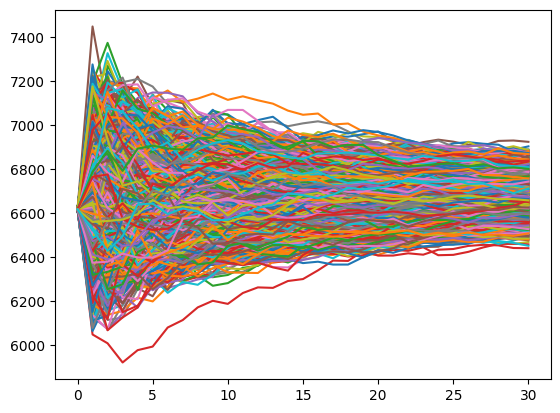

In [ ]:
plt.plot(S2) #Medias acumuladas
plt.show()